Завдання 1
Загрузити датасет Global YouTube Statistics 2023

1. Прочитайте CSV файл

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('Global YouTube Statistics.csv', encoding='ISO-8859-1')

2. Виведіть перші п'ять рядків

In [37]:
df1.head(5)

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


3. Виведіть розміри датасету, перевірте наявність пропусків, дублікатів

In [38]:
print("Формат:", df1.shape)
print("Пусті значення:\n", df1.isna().sum())
print("Дублікати:", df1.duplicated().sum())

Формат: (995, 28)
Пусті значення:
 rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month            

4. Якщо є пропуски, замінить тип даних на float і середнє значення за
стовпцем.

In [40]:
for c in df1.select_dtypes(include='number').columns:
    df1[c] = df1[c].fillna(df1[c].mean())

5. Ще раз перевірте кількість пропусків.

In [41]:
print("Залишилось пустих:", df1.isna().sum().sum())

Залишилось пустих: 325


6. Перевірте, скільки унікальних країн представлено у колонці "Country"

In [42]:
print("Кількість унікальних країн:", len(df1['Country'].dropna().unique()))

Кількість унікальних країн: 49


7. Побудуйте діаграму розподілу переглядів

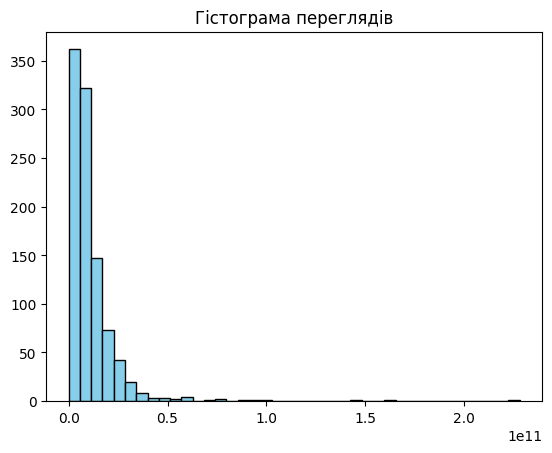

In [43]:
plt.hist(df1['video views'].dropna(), bins=40, color='skyblue', edgecolor='black')
plt.title("Гістограма переглядів")
plt.show()

8. Визначте максимальну, мінімальну, середню кількість переглядів

In [44]:
print("Макс:", df1['video views'].max())
print("Мін:", df1['video views'].min())
print("Середнє:", df1['video views'].mean())

Макс: 228000000000.0
Мін: 0.0
Середнє: 11039537052.03819


9. Знайдіть країну, де найбільше відео було завантажено на YouTube

In [45]:
print(df1.groupby('Country')['uploads'].sum().sort_values(ascending=False).index[0])

India


10. Знайдіть відео з найбільшою та найменшою кількістю завантажень uploads

In [46]:
print(df1[df1['uploads'] == df1['uploads'].max()]['Title'].iloc[0])
print(df1[df1['uploads'] == df1['uploads'].min()]['Title'].iloc[0])

ABP NEWS
Music


2. Зчитати архів Customer Shopping Trends Dataset
Далі працюємо з файлом shopping_trends.csv
Загрузіть цей файл. Перевірте розмір таблиці, наявність пропусків, тип
стовпців. Перейменуйте назви стовпців: Змініть прописні букви на строчні
(маленькі) та пробіл на підкреслення.
Далі виконайте наступні завдання. Побудуйте графіки з використанням
бібліотеки seaborn.

1. Побудуйте гістограму віку клієнтів, використовуючи Seaborn.

(3900, 19)
customer_id                 0
age                         0
gender                      0
item_purchased              0
category                    0
purchase_amount_(usd)       0
location                    0
size                        0
color                       0
season                      0
review_rating               0
subscription_status         0
payment_method              0
shipping_type               0
discount_applied            0
promo_code_used             0
previous_purchases          0
preferred_payment_method    0
frequency_of_purchases      0
dtype: int64


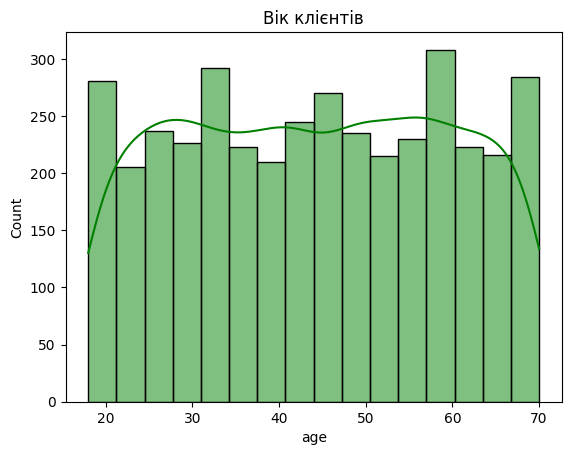

In [47]:
shop_data = pd.read_csv('shopping_trends.csv')
shop_data.columns = [col.strip().lower().replace(' ', '_') for col in shop_data.columns]
print(shop_data.shape)
print(shop_data.isna().sum())

sns.histplot(data=shop_data, x='age', kde=True, color='green')
plt.title('Вік клієнтів')
plt.show()

3. Розподіл покупок за статтею (item_purchased)

/tmp/ipykernel_3795/232366324.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




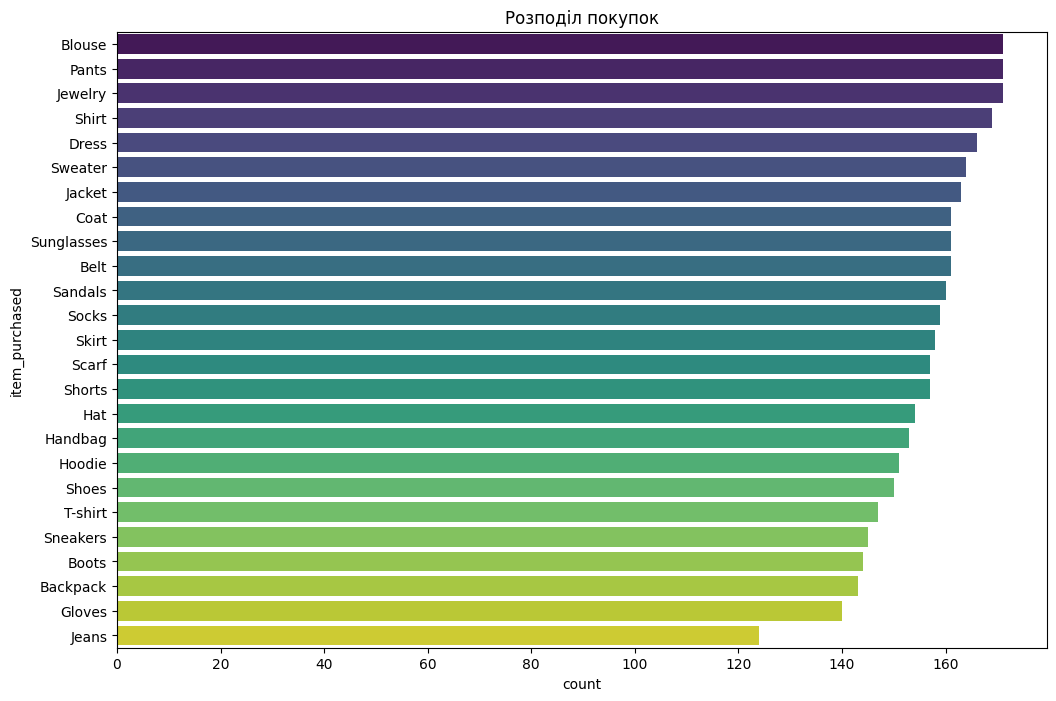

In [48]:
plt.figure(figsize=(12, 8))
sns.countplot(y=shop_data['item_purchased'], order=shop_data['item_purchased'].value_counts().index, palette='viridis')
plt.title('Розподіл покупок')
plt.show()

5. Залежність між віком та сумою покупок

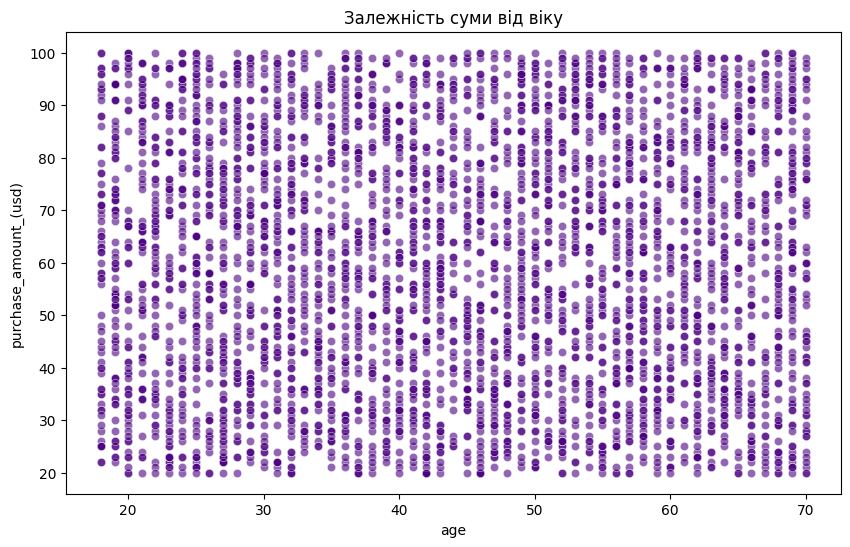

In [49]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=shop_data, x='age', y='purchase_amount_(usd)', alpha=0.6, color='indigo')
plt.title('Залежність суми від віку')
plt.show()

6. Графік розподілу оцінок товарів

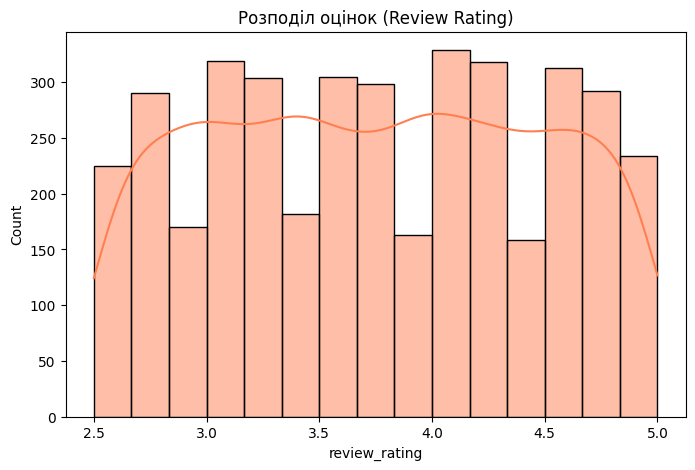

In [52]:
plt.figure(figsize=(8, 5))
sns.histplot(shop_data['review_rating'], bins=15, color='coral', kde=True)
plt.title('Розподіл оцінок (Review Rating)')
plt.show()

8. Категоріальна діаграма для статі

/tmp/ipykernel_3795/3907193514.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




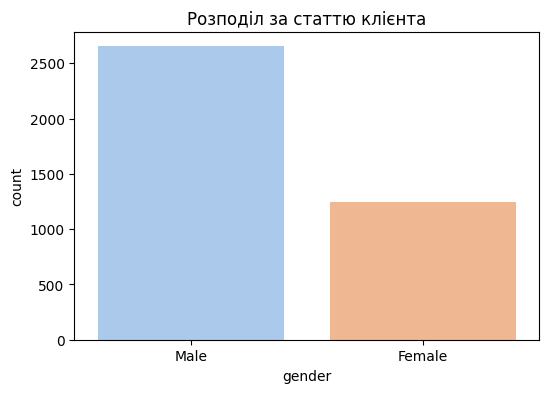

In [53]:
plt.figure(figsize=(6, 4))
sns.countplot(data=shop_data, x='gender', palette='pastel')
plt.title('Розподіл за статтю клієнта')
plt.show()

10. Залежність між рейтингом і сумою покупок

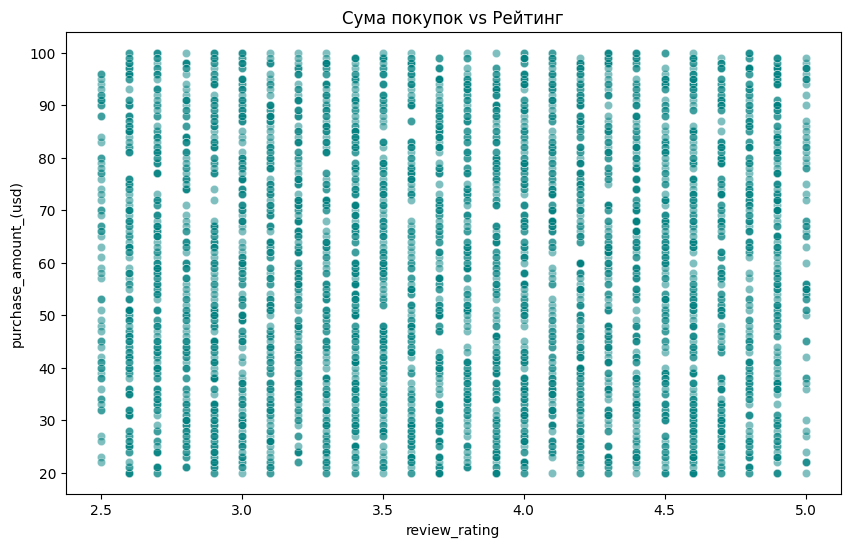

In [54]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=shop_data, x='review_rating', y='purchase_amount_(usd)', color='teal', alpha=0.5)
plt.title('Сума покупок vs Рейтинг')
plt.show()

Завдання 3

1. Створіть горизонтальну діаграму з мітками на основі даних про
врожайність пшениці (data.wheat()) за допомогою бібліотеки Altair.
Задайте вісь x для врожайності пшениці, вісь y для років, а текстові
мітки відображайте значення врожайності пшениці на відповідних
роках.

In [56]:
import altair as alt
from vega_datasets import data

df_wheat = data.wheat()

base = alt.Chart(df_wheat).encode(
    x=alt.X('wheat:Q', title='Врожайність пшениці'),
    y=alt.Y('year:O', title='Рік')
)

bars = base.mark_bar()
text = base.mark_text(align='left', baseline='middle', dx=3).encode(text='wheat:Q')

chart1 = (bars + text).properties(title='Врожайність пшениці за роками', width=600)
chart1.display()

alt.LayerChart(...)

2. Створіть багатошарову діаграму на основі даних про виробництво
електроенергії в штаті Айова (data.iowa_electricity()) за допомогою
бібліотеки Altair . Вісь x представляє роки, вісь y відображає чисте
виробництво електроенергії (net_generation), а кожен шар діаграми
позначає різні джерела енергії (source). Встановіть прозорість (opacity)
для стовпців на рівні 0.7.

In [57]:
import altair as alt
from vega_datasets import data

df_iowa = data.iowa_electricity()

chart2 = alt.Chart(df_iowa).mark_bar(opacity=0.7).encode(
    x=alt.X('year:T', title='Рік'),
    y=alt.Y('net_generation:Q', title='Чисте виробництво електроенергії'),
    color=alt.Color('source:N', title='Джерело енергії')
).properties(title='Виробництво електроенергії в штаті Айова', width=600, height=400)

chart2.display()

alt.Chart(...)

3. Створіть графік за допомогою бібліотеки Plotly (scatter plot) для даних
ірисів (iris dataset), де:
Вісь X (x-axis) відповідає ширині чашелистика (sepal width).
Вісь Y (y-axis) відповідає довжині чашелистика (sepal length).
Кожен пункт на графіку має розмір, який залежить від довжини
пелюстки (petal length).
Кожен пункт на графіку має різний колір в залежності від виду
(species).
При наведенні на пункт повинні відображатися додаткові дані, такі як
ширина пелюстки (petal width)

In [58]:
import plotly.express as px

df_iris = px.data.iris()

fig = px.scatter(
    df_iris,
    x="sepal_width",
    y="sepal_length",
    size="petal_length",
    color="species",
    hover_data=["petal_width"],
    labels={
        "sepal_width": "Ширина чашелистика",
        "sepal_length": "Довжина чашелистика",
        "petal_length": "Довжина пелюстки",
        "species": "Вид",
        "petal_width": "Ширина пелюстки"
    }
)

fig.show()